# 🦷 Análisis Exploratorio de Datos (EDA)
## Clasificación de Cáncer Bucal — Dataset de Imágenes

---

**Objetivo:** Realizar un análisis exploratorio exhaustivo del dataset de imágenes médicas para la clasificación binaria de cáncer bucal (*Oral Cancer* vs *Normal*), identificando características estadísticas, distribuciones, calidad de datos y hallazgos clave que guíen el proceso de preprocesamiento y modelado.

**Clases:**
- `Oral Cancer photos` → Imágenes con presencia de cáncer bucal
- `normal` → Imágenes de cavidad oral sana

---

## 1. Importación de Librerías

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Configuración de estilo global
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Paleta de colores del proyecto
PALETTE = {
    'cancer': '#E63946',
    'normal': '#2A9D8F',
    'accent': '#457B9D',
    'bg_dark': '#1D3557',
    'neutral': '#A8DADC'
}

print('✅ Librerías importadas correctamente.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')
print(f'   PIL    : {Image.__version__}')

✅ Librerías importadas correctamente.
   NumPy  : 2.2.6
   Pandas : 2.3.3
   PIL    : 12.1.1


---
## 2. Carga y Estructuración del Dataset

In [3]:
# ── Rutas ────────────────────────────────────────────────────────────────────
BASE_DIR    = Path('dataset')
CLASS_MAP   = {
    'Oral Cancer photos': 1,
    'normal':             0
}
VALID_EXT   = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.jfif'}

# ── Recolección de metadatos ─────────────────────────────────────────────────
records = []
for class_name, label in CLASS_MAP.items():
    class_dir = BASE_DIR / class_name
    for fp in class_dir.iterdir():
        if fp.suffix.lower() in VALID_EXT:
            records.append({
                'filepath'    : str(fp),
                'filename'    : fp.name,
                'class_name'  : class_name,
                'label'       : label,
                'extension'   : fp.suffix.lower(),
                'file_size_kb': fp.stat().st_size / 1024
            })

df = pd.DataFrame(records)
print(f"📦 Total de imágenes cargadas : {len(df):,}")
print(f"   Clases encontradas         : {df['class_name'].unique().tolist()}")
df.head()

📦 Total de imágenes cargadas : 1,238
   Clases encontradas         : ['Oral Cancer photos', 'normal']


,filepath,filename,class_name,label,extension,file_size_kb
0,dataset\Oral Cancer photos\001.jpeg,001.jpeg,Oral Cancer photos,1,.jpeg,25.972656
1,dataset\Oral Cancer photos\002.jpeg,002.jpeg,Oral Cancer photos,1,.jpeg,40.929688
2,dataset\Oral Cancer photos\003.jpeg,003.jpeg,Oral Cancer photos,1,.jpeg,42.513672
3,dataset\Oral Cancer photos\004.jpeg,004.jpeg,Oral Cancer photos,1,.jpeg,42.286133
4,dataset\Oral Cancer photos\005.jpeg,005.jpeg,Oral Cancer photos,1,.jpeg,130.797852


---
## 3. Extracción de Metadatos de Imagen
Para cada imagen se extraen: resolución (ancho × alto), relación de aspecto, número de canales y estadísticas de color en los canales RGB.

In [4]:
def extract_image_metadata(filepath: str) -> dict:
    """Extrae metadatos estadísticos de una imagen usando PIL."""
    try:
        img_pil = Image.open(filepath).convert('RGB')
        w, h = img_pil.size
        img_np = np.array(img_pil)

        gray = np.array(img_pil.convert('L'))
        metadata = {
            'width'        : w,
            'height'       : h,
            'aspect_ratio' : round(w / h, 3),
            'num_channels' : img_np.shape[2] if img_np.ndim == 3 else 1,
            'mean_r'       : img_np[:, :, 0].mean(),
            'mean_g'       : img_np[:, :, 1].mean(),
            'mean_b'       : img_np[:, :, 2].mean(),
            'std_r'        : img_np[:, :, 0].std(),
            'std_g'        : img_np[:, :, 1].std(),
            'std_b'        : img_np[:, :, 2].std(),
            'global_mean'  : img_np.mean(),
            'global_std'   : img_np.std(),
            'brightness'   : gray.mean(),
            'contrast'     : gray.std(),
            'is_corrupt'   : False
        }
    except Exception:
        metadata = {k: np.nan for k in [
            'width','height','aspect_ratio','num_channels',
            'mean_r','mean_g','mean_b','std_r','std_g','std_b',
            'global_mean','global_std','brightness','contrast'
        ]}
        metadata['is_corrupt'] = True
    return metadata

# Extracción (puede tardar ~1-2 min según hardware)
print('🔍 Extrayendo metadatos de imágenes...')
meta_list = [extract_image_metadata(fp) for fp in df['filepath']]
df_meta   = pd.DataFrame(meta_list)
df        = pd.concat([df.reset_index(drop=True), df_meta], axis=1)

corrupted = df['is_corrupt'].sum()
print(f'✅ Extracción completa.  Imágenes corruptas: {corrupted}')
df.describe().T

🔍 Extrayendo metadatos de imágenes...
✅ Extracción completa.  Imágenes corruptas: 0


,count,mean,std,min,25%,50%,75%,max
label,1238.0,0.553312,0.497351,0.000000,0.000000,1.000000,1.000000,1.000000
file_size_kb,1238.0,167.685335,552.001767,2.648438,31.018311,52.658203,87.512695,10091.332031
width,1238.0,709.043619,685.599546,90.000000,331.000000,500.000000,800.000000,9248.000000
height,1238.0,682.617932,702.051015,89.000000,276.250000,473.000000,795.500000,6936.000000
aspect_ratio,1238.0,1.153274,0.356033,0.450000,0.892250,1.144000,1.437000,2.765000
num_channels,1238.0,3.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000
mean_r,1238.0,163.186536,28.106251,62.502839,144.561310,163.967430,182.056704,247.448851
mean_g,1238.0,115.351452,23.533766,41.489784,100.253298,114.727760,130.356874,209.647617
mean_b,1238.0,110.505635,25.471127,43.393779,93.224042,110.731029,127.339303,220.160413
std_r,1238.0,49.250636,13.802859,10.152004,39.022801,49.309995,58.740333,94.969738


---
## 4. Balance de Clases

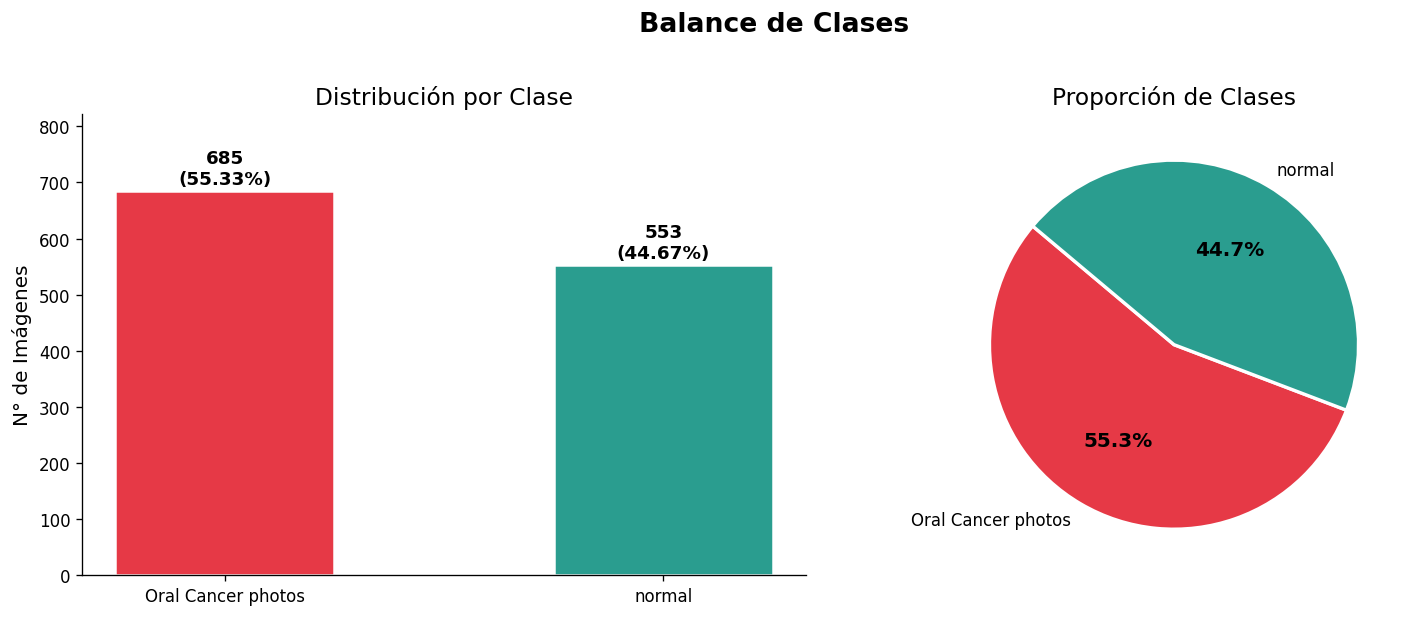


─────────────────────────────────────────────
  Clase                    Count    %
─────────────────────────────────────────────
  Oral Cancer photos          685   55.3%
  normal                      553   44.7%
─────────────────────────────────────────────
  TOTAL                    1,238  100.0%
  Ratio de desbalance       1.24x
─────────────────────────────────────────────


In [5]:
counts    = df['class_name'].value_counts()
pct       = (counts / counts.sum() * 100).round(2)
imbalance = (counts.max() / counts.min()).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Balance de Clases', fontsize=16, fontweight='bold', y=1.02)

colors = [PALETTE['cancer'], PALETTE['normal']]
bars   = axes[0].bar(counts.index, counts.values, color=colors, width=0.5,
                     edgecolor='white', linewidth=1.5)
for bar, v, p in zip(bars, counts.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{v:,}\n({p}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Distribución por Clase')
axes[0].set_ylabel('N° de Imágenes')
axes[0].set_ylim(0, counts.max() * 1.2)

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.show()

print(f"\n{'─'*45}")
print(f"  Clase                    Count    %")
print(f"{'─'*45}")
for cn, c, p in zip(counts.index, counts.values, pct.values):
    print(f"  {cn:<25} {c:>5,}  {p:>5.1f}%")
print(f"{'─'*45}")
print(f"  TOTAL                    {counts.sum():>5,}  100.0%")
print(f"  Ratio de desbalance      {imbalance:>5.2f}x")
print(f"{'─'*45}")

---
## 5. Distribución de Formatos y Tipos de Archivo

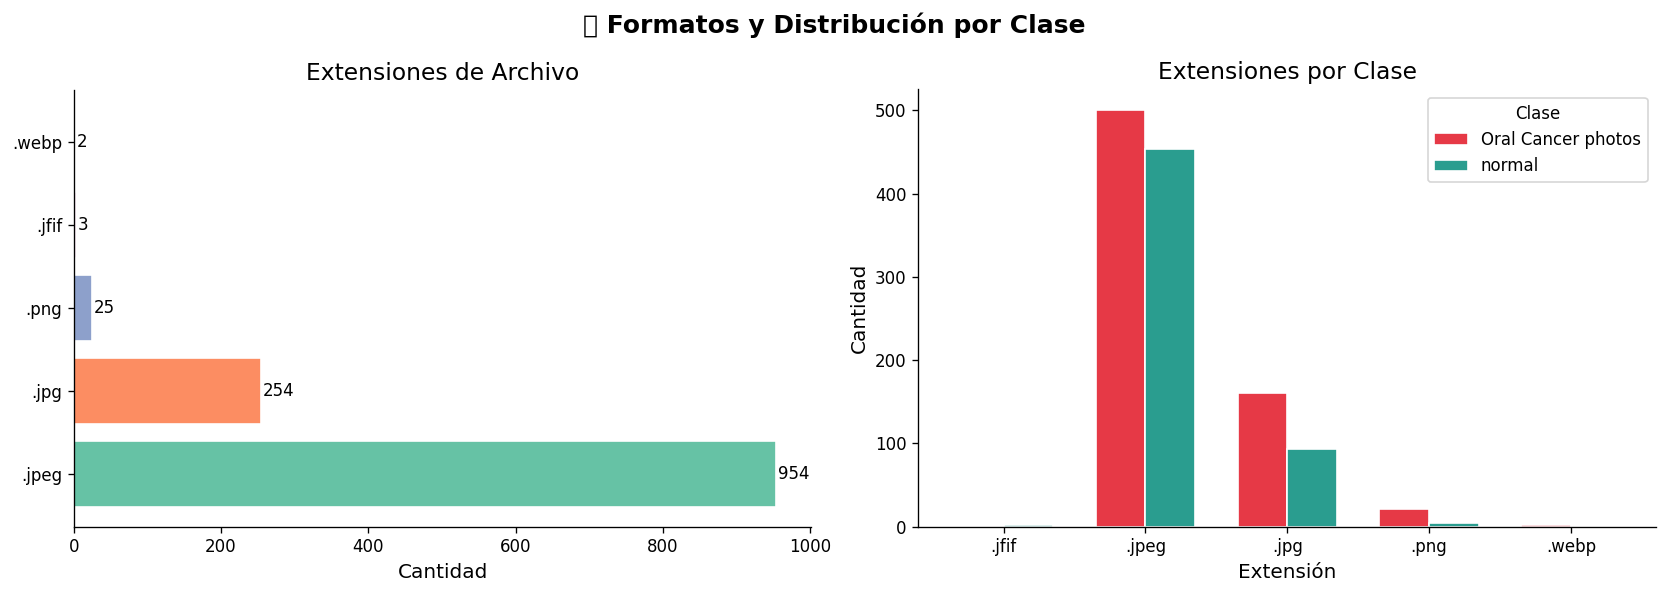


🔎 Resumen de formatos:
extension
.jpeg    954
.jpg     254
.png      25
.jfif      3
.webp      2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📁 Formatos y Distribución por Clase', fontsize=15, fontweight='bold')

ext_counts = df['extension'].value_counts()
palette_ext = sns.color_palette('Set2', len(ext_counts))
bars = axes[0].barh(ext_counts.index, ext_counts.values, color=palette_ext, edgecolor='white')
for bar, v in zip(bars, ext_counts.values):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=10)
axes[0].set_title('Extensiones de Archivo')
axes[0].set_xlabel('Cantidad')

ext_class = df.groupby(['extension','class_name']).size().unstack(fill_value=0)
ext_class.plot(kind='bar', ax=axes[1],
               color=[PALETTE['cancer'], PALETTE['normal']],
               edgecolor='white', width=0.7)
axes[1].set_title('Extensiones por Clase')
axes[1].set_xlabel('Extensión')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Clase')

plt.tight_layout()
plt.show()

print("\n🔎 Resumen de formatos:")
print(ext_counts.to_string())

---
## 6. Análisis de Resoluciones y Dimensiones

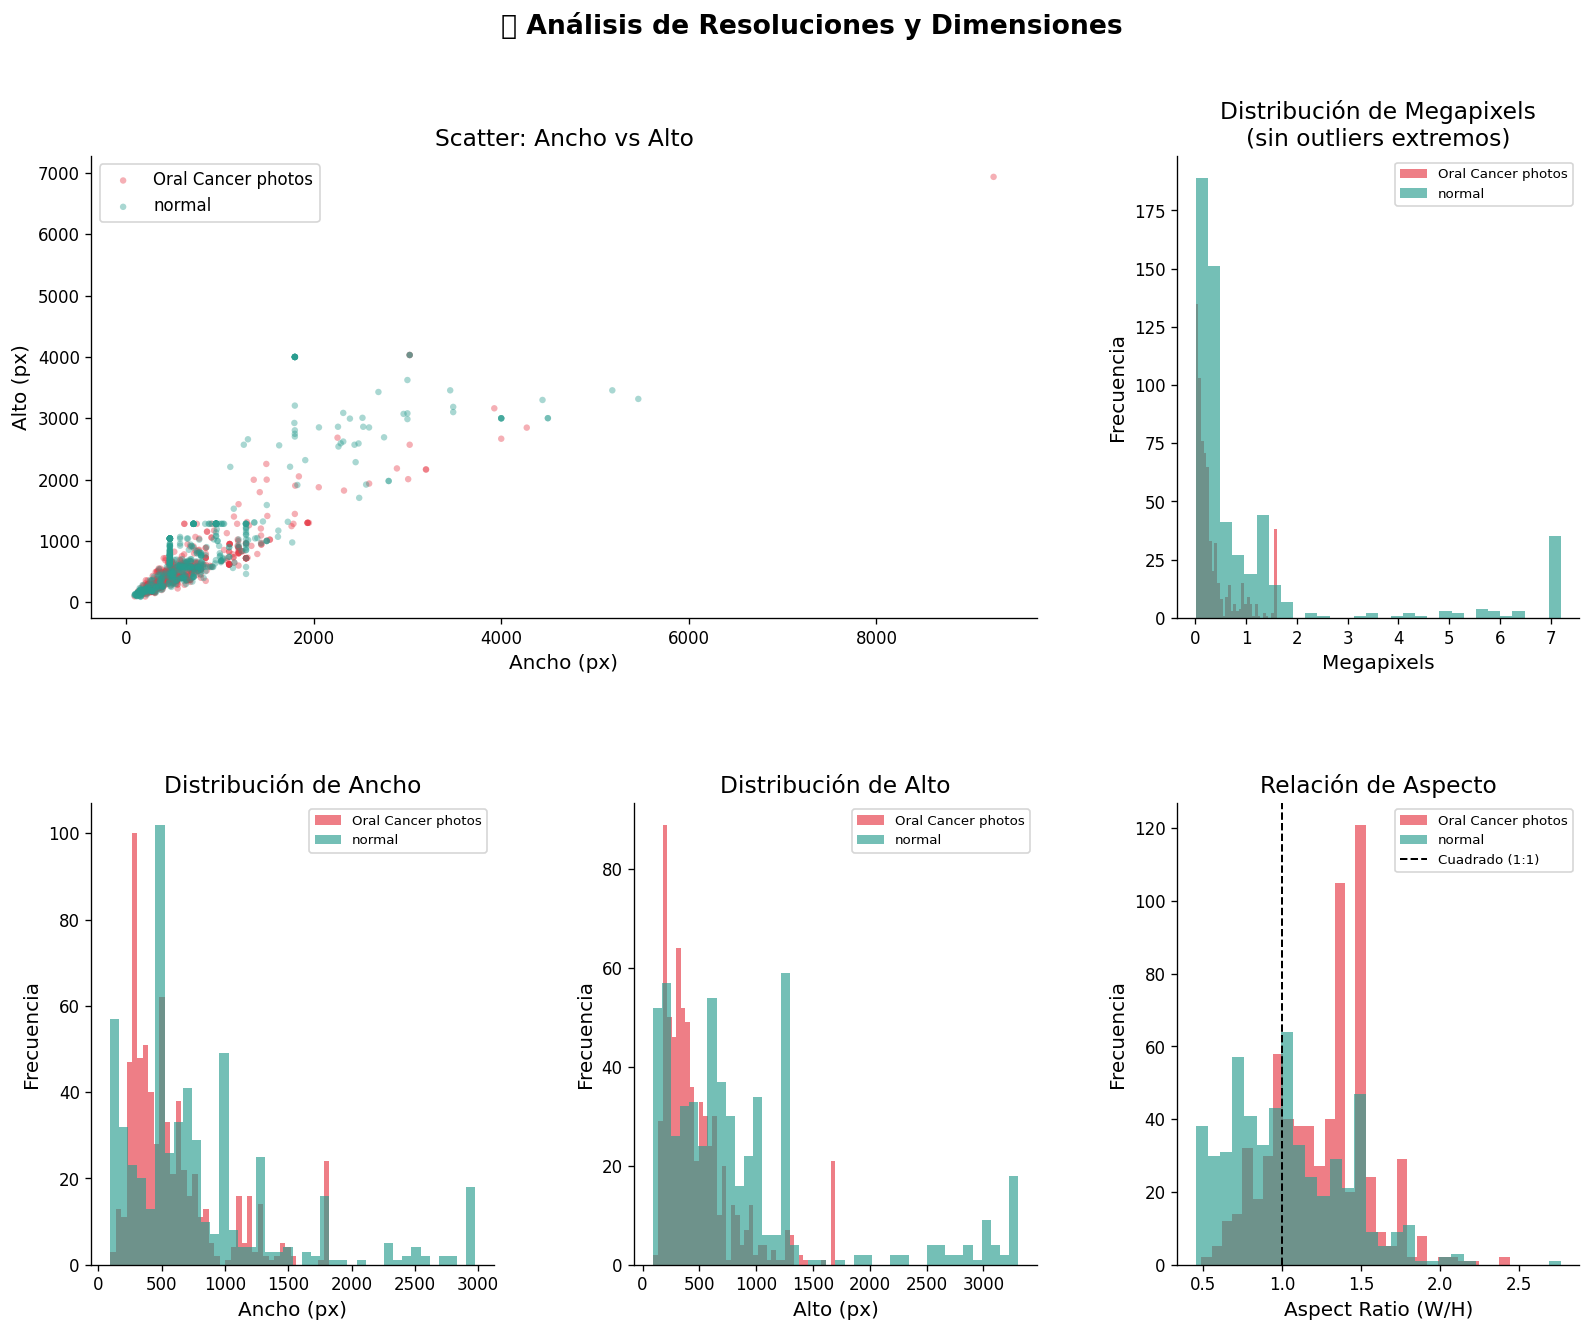


📏 Estadísticas de resolución por clase:


width                                                   \
                    count   mean    std   min    25%    50%    75%     max   
class_name                                                                   
Oral Cancer photos  685.0  623.1  598.1  93.0  308.0  487.0  698.0  9248.0   
normal              553.0  815.5  767.9  90.0  392.0  599.0  960.0  5461.0   

                   height         ... megapixels       aspect_ratio            \
                    count   mean  ...        75%   max        count mean  std   
class_name                        ...                                           
Oral Cancer photos  685.0  516.9  ...        0.4  64.1        685.0  1.3  0.3   
normal              553.0  887.9  ...        1.0  18.1        553.0  1.0  0.4   

                                             
                    min  25%  50%  75%  max  
class_name                                   
Oral Cancer photos  0.5  1.0  1.3  1.5  2.4  
normal              0.4  0.8  1.0  1.3  2.8  

[2 rows x 32 columns]

In [7]:
df_valid = df[~df['is_corrupt']].copy()
df_valid['megapixels'] = (df_valid['width'] * df_valid['height']) / 1e6

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('📐 Análisis de Resoluciones y Dimensiones', fontsize=16, fontweight='bold')

ax0 = fig.add_subplot(gs[0, 0:2])
for class_name, color in [('Oral Cancer photos', PALETTE['cancer']), ('normal', PALETTE['normal'])]:
    sub = df_valid[df_valid['class_name'] == class_name]
    ax0.scatter(sub['width'], sub['height'], alpha=0.4, s=15,
                color=color, label=class_name, edgecolors='none')
ax0.set_xlabel('Ancho (px)')
ax0.set_ylabel('Alto (px)')
ax0.set_title('Scatter: Ancho vs Alto')
ax0.legend()

ax1 = fig.add_subplot(gs[0, 2])
for class_name, color in [('Oral Cancer photos', PALETTE['cancer']), ('normal', PALETTE['normal'])]:
    sub = df_valid[df_valid['class_name'] == class_name]
    ax1.hist(sub['megapixels'].clip(upper=sub['megapixels'].quantile(0.95)),
             bins=30, alpha=0.65, color=color, label=class_name, edgecolor='none')
ax1.set_xlabel('Megapixels')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de Megapixels\n(sin outliers extremos)')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[1, 0])
for class_name, color in [('Oral Cancer photos', PALETTE['cancer']), ('normal', PALETTE['normal'])]:
    sub = df_valid[df_valid['class_name'] == class_name]
    ax2.hist(sub['width'].clip(upper=sub['width'].quantile(0.97)),
             bins=40, alpha=0.65, color=color, label=class_name, edgecolor='none')
ax2.set_xlabel('Ancho (px)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Ancho')
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[1, 1])
for class_name, color in [('Oral Cancer photos', PALETTE['cancer']), ('normal', PALETTE['normal'])]:
    sub = df_valid[df_valid['class_name'] == class_name]
    ax3.hist(sub['height'].clip(upper=sub['height'].quantile(0.97)),
             bins=40, alpha=0.65, color=color, label=class_name, edgecolor='none')
ax3.set_xlabel('Alto (px)')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Alto')
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 2])
for class_name, color in [('Oral Cancer photos', PALETTE['cancer']), ('normal', PALETTE['normal'])]:
    sub = df_valid[df_valid['class_name'] == class_name]
    sub_ar = sub['aspect_ratio'].clip(lower=0.2, upper=5)
    ax4.hist(sub_ar, bins=30, alpha=0.65, color=color, label=class_name, edgecolor='none')
ax4.axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='Cuadrado (1:1)')
ax4.set_xlabel('Aspect Ratio (W/H)')
ax4.set_ylabel('Frecuencia')
ax4.set_title('Relación de Aspecto')
ax4.legend(fontsize=8)

plt.show()

print("\n📏 Estadísticas de resolución por clase:")
res_stats = df_valid.groupby('class_name')[['width','height','megapixels','aspect_ratio']].describe().round(1)
display(res_stats)

---
## 7. Análisis de Tamaño de Archivo

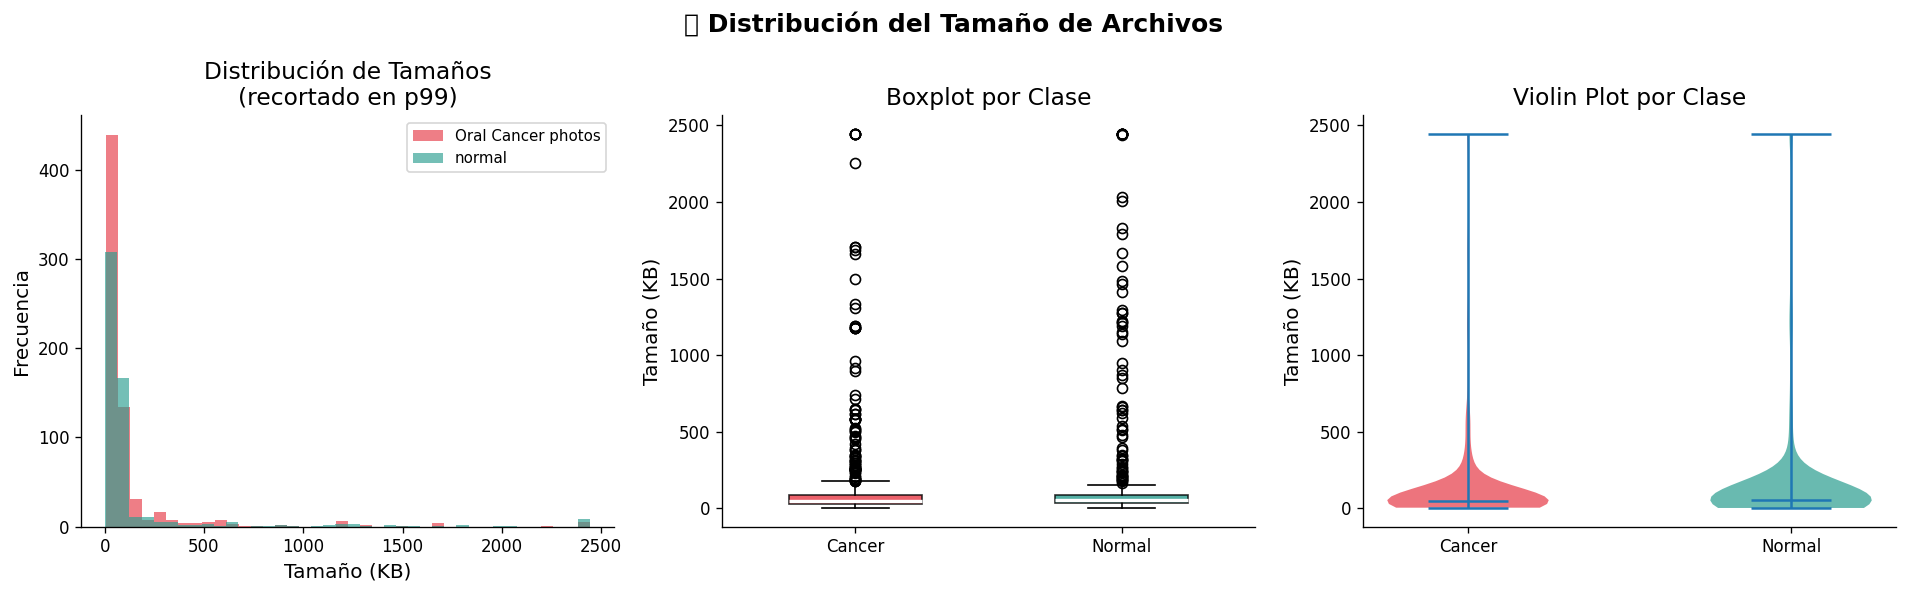


💾 Estadísticas de tamaño de archivo por clase (KB):


,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
Oral Cancer photos,685.0,146.76,514.02,4.56,26.21,49.32,86.54,10091.33
normal,553.0,193.61,595.16,2.65,36.29,56.64,88.01,6718.94


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('💾 Distribución del Tamaño de Archivos', fontsize=15, fontweight='bold')

clamp = df_valid['file_size_kb'].quantile(0.99)

for class_name, color in [('Oral Cancer photos', PALETTE['cancer']), ('normal', PALETTE['normal'])]:
    sub = df_valid[df_valid['class_name'] == class_name]
    axes[0].hist(sub['file_size_kb'].clip(upper=clamp),
                 bins=40, alpha=0.65, color=color, label=class_name, edgecolor='none')
axes[0].set_xlabel('Tamaño (KB)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Tamaños\n(recortado en p99)')
axes[0].legend(fontsize=9)

bp_data = [df_valid[df_valid['class_name'] == c]['file_size_kb'].clip(upper=clamp)
           for c in ['Oral Cancer photos','normal']]
bp = axes[1].boxplot(bp_data, patch_artist=True, widths=0.5,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [PALETTE['cancer'], PALETTE['normal']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticklabels(['Cancer', 'Normal'])
axes[1].set_ylabel('Tamaño (KB)')
axes[1].set_title('Boxplot por Clase')

vp = axes[2].violinplot(bp_data, positions=[1, 2], showmedians=True)
for body, color in zip(vp['bodies'], [PALETTE['cancer'], PALETTE['normal']]):
    body.set_facecolor(color)
    body.set_alpha(0.7)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Cancer', 'Normal'])
axes[2].set_ylabel('Tamaño (KB)')
axes[2].set_title('Violin Plot por Clase')

plt.tight_layout()
plt.show()

print("\n💾 Estadísticas de tamaño de archivo por clase (KB):")
size_stats = df_valid.groupby('class_name')['file_size_kb'].describe().round(2)
display(size_stats)

---
## 8. Análisis de Color — Medias RGB por Clase

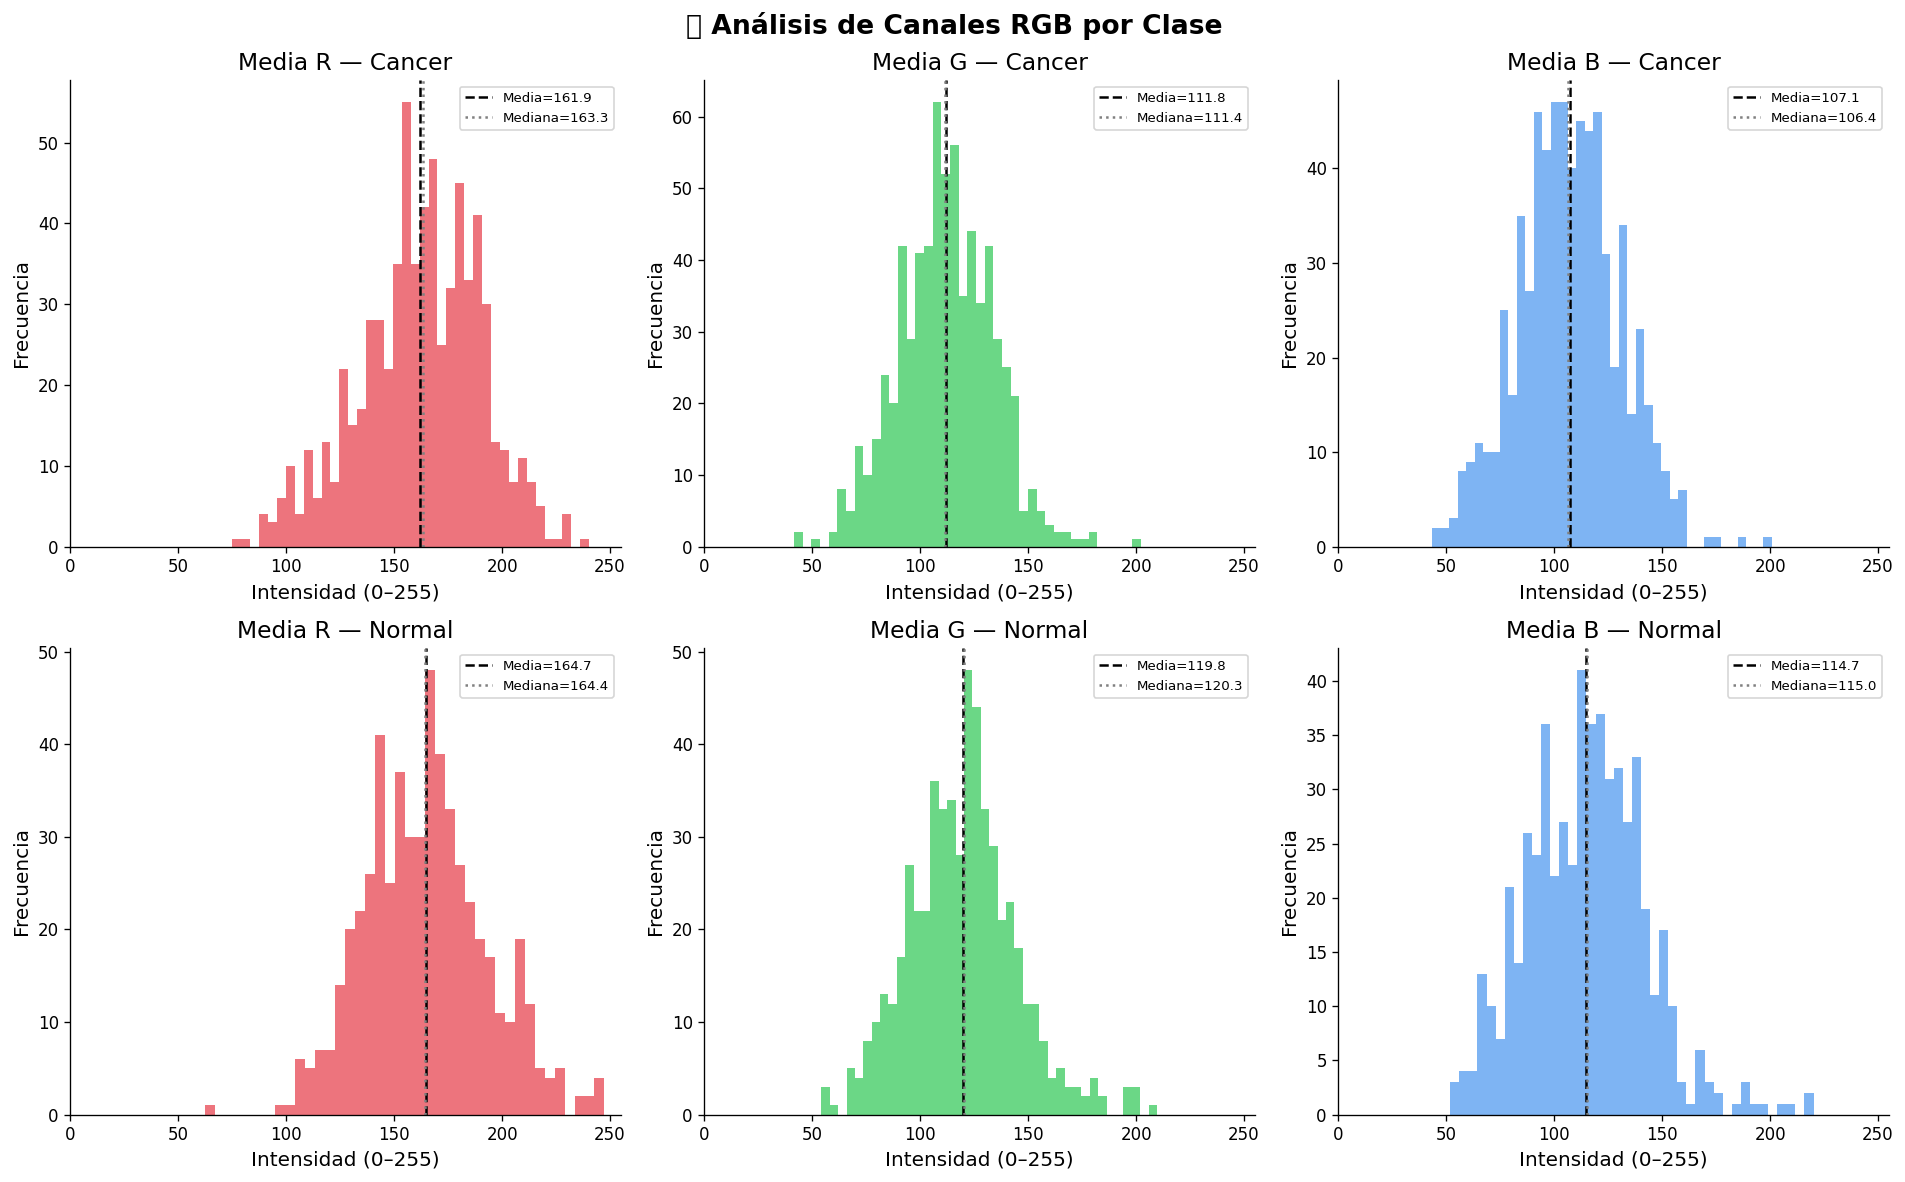


🎨 Estadísticas RGB medias por clase:


,mean_r,mean_g,mean_b,std_r,std_g,std_b
class_name,,,,,,
Oral Cancer photos,161.95,111.78,107.08,47.04,47.57,46.01
normal,164.72,119.77,114.74,51.99,51.80,50.19


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('🎨 Análisis de Canales RGB por Clase', fontsize=16, fontweight='bold')

channels = [('mean_r', 'Media R', '#E63946'), ('mean_g', 'Media G', '#2DC653'), ('mean_b', 'Media B', '#4895EF')]

for col_idx, (col, label, ch_color) in enumerate(channels):
    for row_idx, (class_name, class_color) in enumerate([('Oral Cancer photos', PALETTE['cancer']),
                                                          ('normal', PALETTE['normal'])]):
        ax = axes[row_idx][col_idx]
        sub = df_valid[df_valid['class_name'] == class_name][col].dropna()

        ax.hist(sub, bins=40, color=ch_color, alpha=0.7, edgecolor='none')
        ax.axvline(sub.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Media={sub.mean():.1f}')
        ax.axvline(sub.median(), color='gray', linestyle=':', linewidth=1.5, label=f'Mediana={sub.median():.1f}')
        ax.set_xlabel('Intensidad (0–255)')
        ax.set_ylabel('Frecuencia')
        short_name = 'Cancer' if 'Cancer' in class_name else 'Normal'
        ax.set_title(f'{label} — {short_name}')
        ax.legend(fontsize=8)
        ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()

print("\n🎨 Estadísticas RGB medias por clase:")
rgb_stats = df_valid.groupby('class_name')[['mean_r','mean_g','mean_b','std_r','std_g','std_b']].mean().round(2)
display(rgb_stats)

---
## 9. Brillo y Contraste por Clase

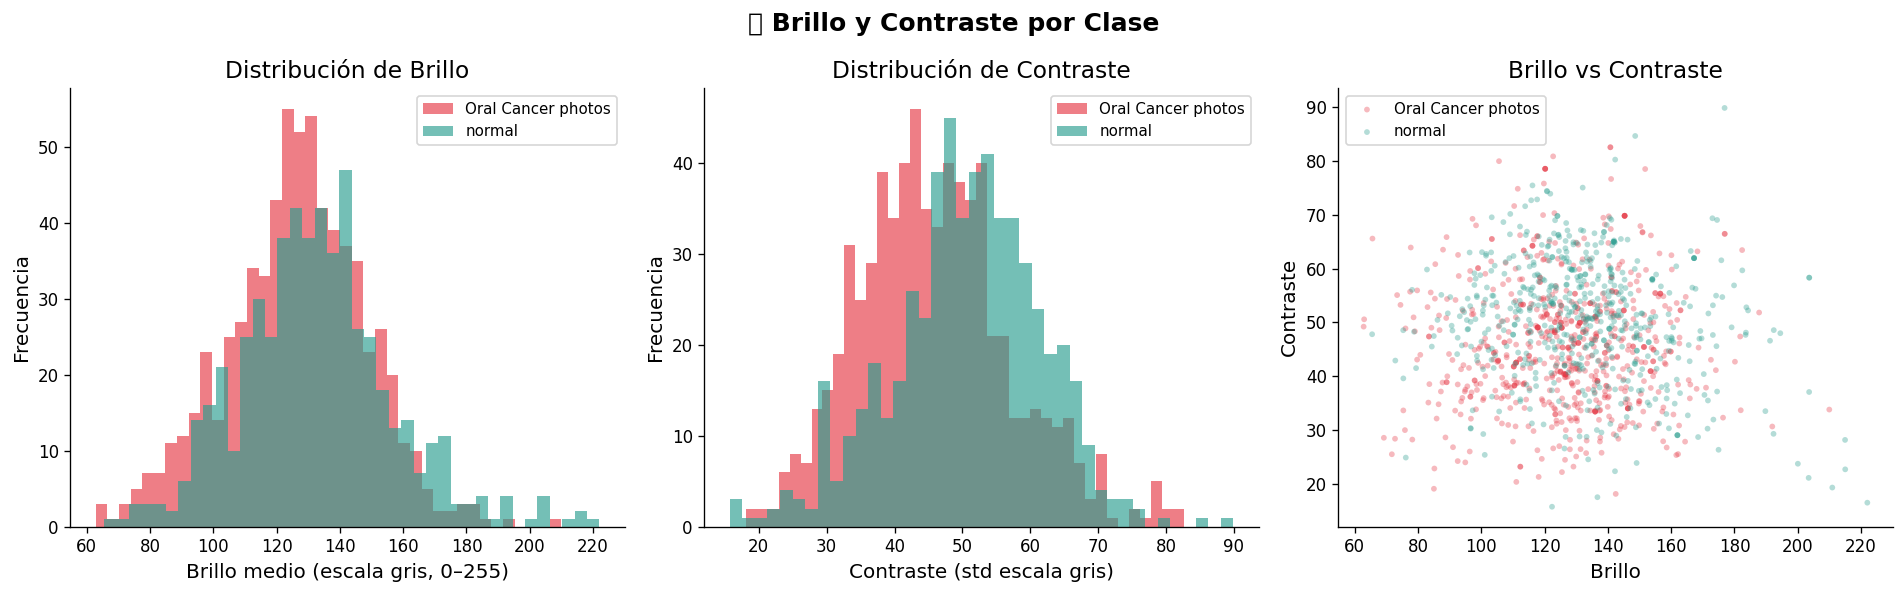


💡 Brillo y contraste medio por clase:
                   brightness                                                \
                        count    mean    std    min     25%     50%     75%   
class_name                                                                    
Oral Cancer photos      685.0  126.25  22.00  62.81  112.33  126.74  140.79   
normal                  553.0  132.65  24.18  65.49  116.65  131.82  145.15   

                           contrast                                            \
                       max    count   mean    std    min    25%    50%    75%   
class_name                                                                      
Oral Cancer photos  209.97    685.0  45.83  11.32  18.09  38.16  45.34  52.40   
normal              221.99    553.0  50.53  11.15  15.70  44.10  51.12  58.04   

                           
                      max  
class_name                 
Oral Cancer photos  82.60  
normal              89.91  


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('💡 Brillo y Contraste por Clase', fontsize=15, fontweight='bold')

for class_name, color in [('Oral Cancer photos', PALETTE['cancer']), ('normal', PALETTE['normal'])]:
    sub = df_valid[df_valid['class_name'] == class_name]
    axes[0].hist(sub['brightness'], bins=40, alpha=0.65, color=color,
                 label=class_name, edgecolor='none')
axes[0].set_xlabel('Brillo medio (escala gris, 0–255)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Brillo')
axes[0].legend(fontsize=9)

for class_name, color in [('Oral Cancer photos', PALETTE['cancer']), ('normal', PALETTE['normal'])]:
    sub = df_valid[df_valid['class_name'] == class_name]
    axes[1].hist(sub['contrast'], bins=40, alpha=0.65, color=color,
                 label=class_name, edgecolor='none')
axes[1].set_xlabel('Contraste (std escala gris)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Contraste')
axes[1].legend(fontsize=9)

for class_name, color in [('Oral Cancer photos', PALETTE['cancer']), ('normal', PALETTE['normal'])]:
    sub = df_valid[df_valid['class_name'] == class_name]
    axes[2].scatter(sub['brightness'], sub['contrast'], alpha=0.35, s=12,
                    color=color, label=class_name, edgecolors='none')
axes[2].set_xlabel('Brillo')
axes[2].set_ylabel('Contraste')
axes[2].set_title('Brillo vs Contraste')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 Brillo y contraste medio por clase:")
print(df_valid.groupby('class_name')[['brightness','contrast']].describe().round(2))

---
## 10. Mapa de Calor de Correlación entre Características

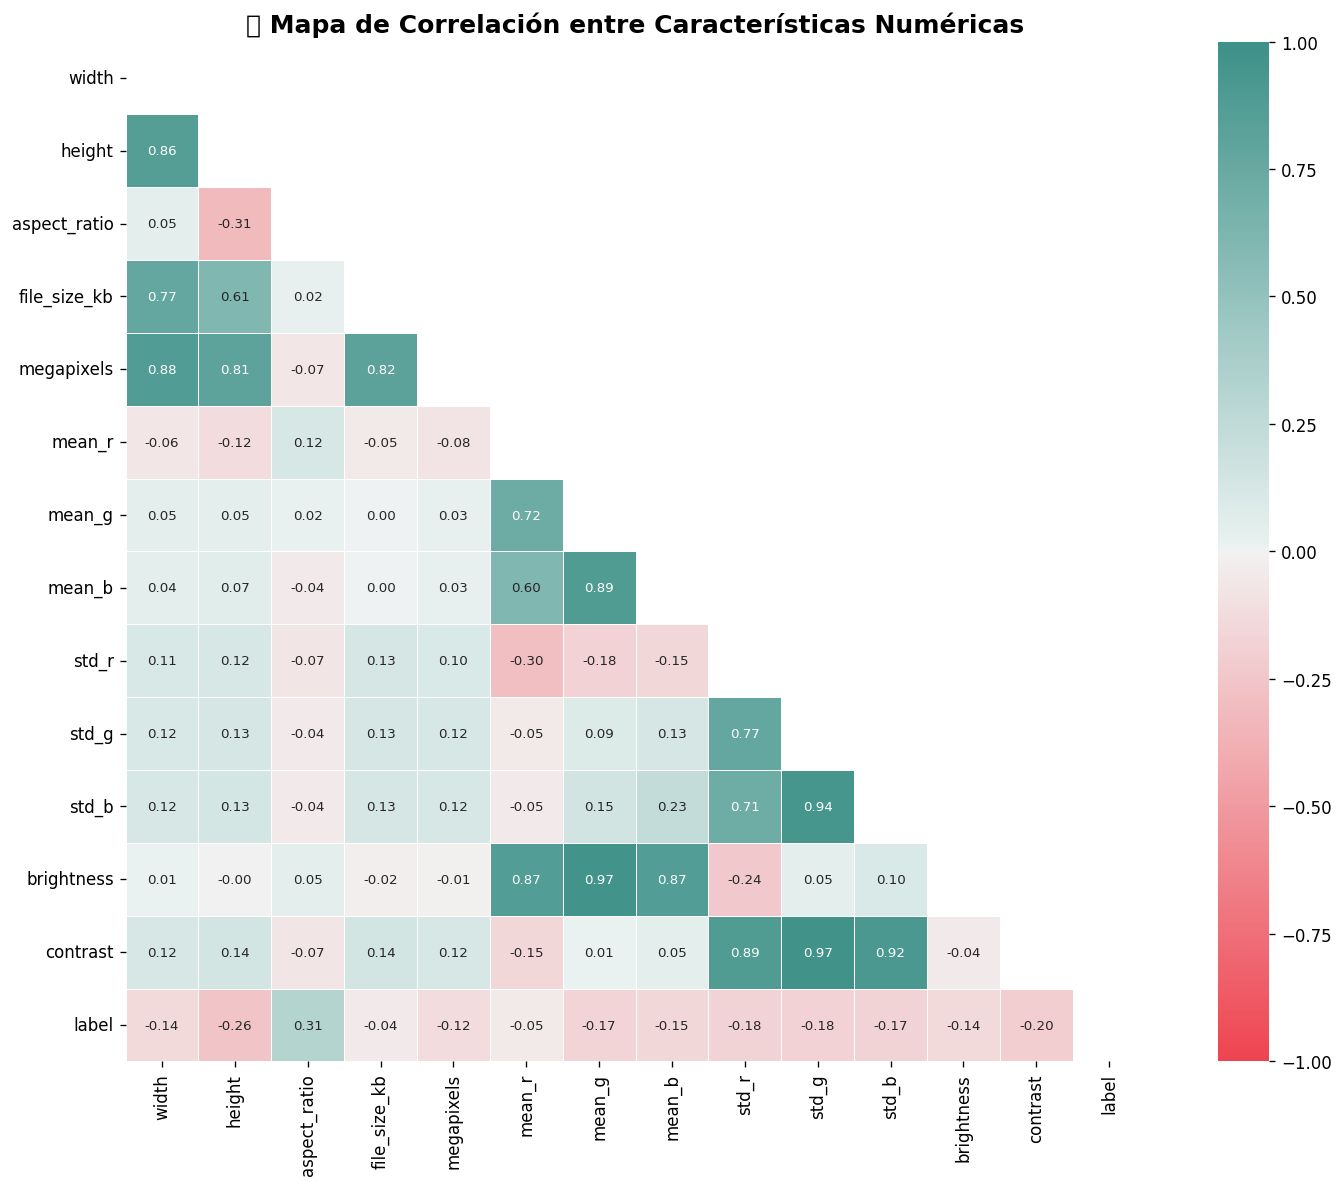


📌 Correlación de características con la etiqueta (label):
aspect_ratio    0.314342
height         -0.262886
contrast       -0.203708
std_g          -0.183780
std_r          -0.178244
std_b          -0.173732
mean_g         -0.168951
mean_b         -0.149567
width          -0.139624
brightness     -0.137008
megapixels     -0.124396
mean_r         -0.049005
file_size_kb   -0.042213


In [11]:
numeric_cols = ['width','height','aspect_ratio','file_size_kb','megapixels',
                'mean_r','mean_g','mean_b','std_r','std_g','std_b',
                'brightness','contrast','label']

df_corr = df_valid[numeric_cols].dropna()
corr    = df_corr.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask    = np.triu(np.ones_like(corr, dtype=bool))
cmap    = sns.diverging_palette(10, 180, s=80, l=55, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('🔗 Mapa de Correlación entre Características Numéricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Correlación de características con la etiqueta (label):")
label_corr = corr['label'].drop('label').sort_values(key=abs, ascending=False)
print(label_corr.to_string())

---
## 11. Visualización de Muestras Representativas

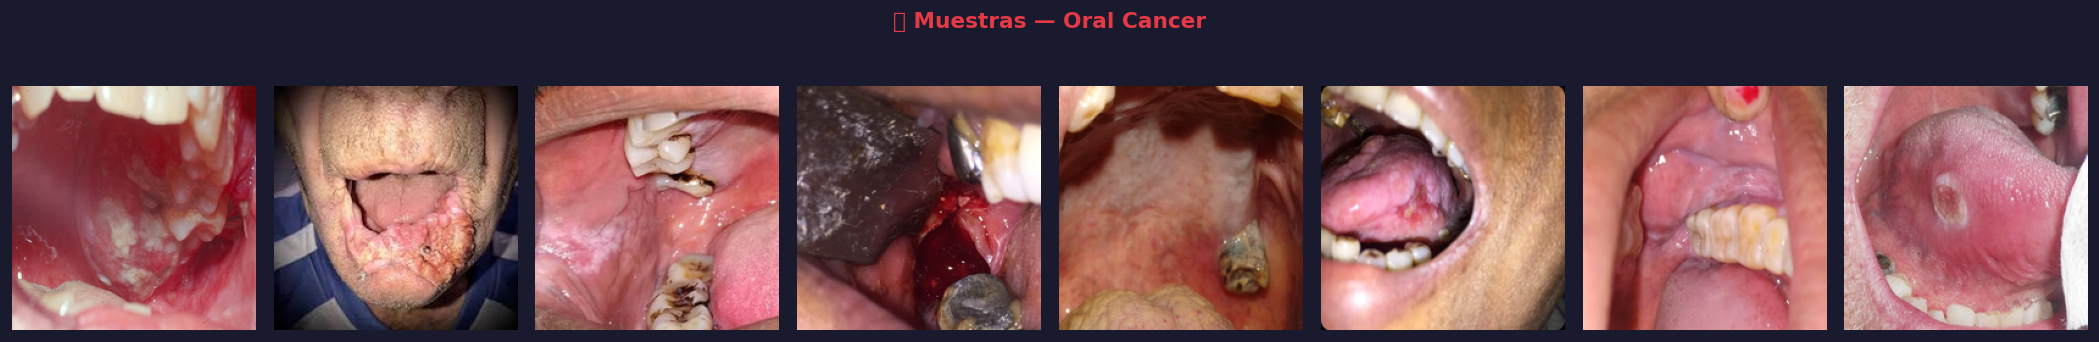

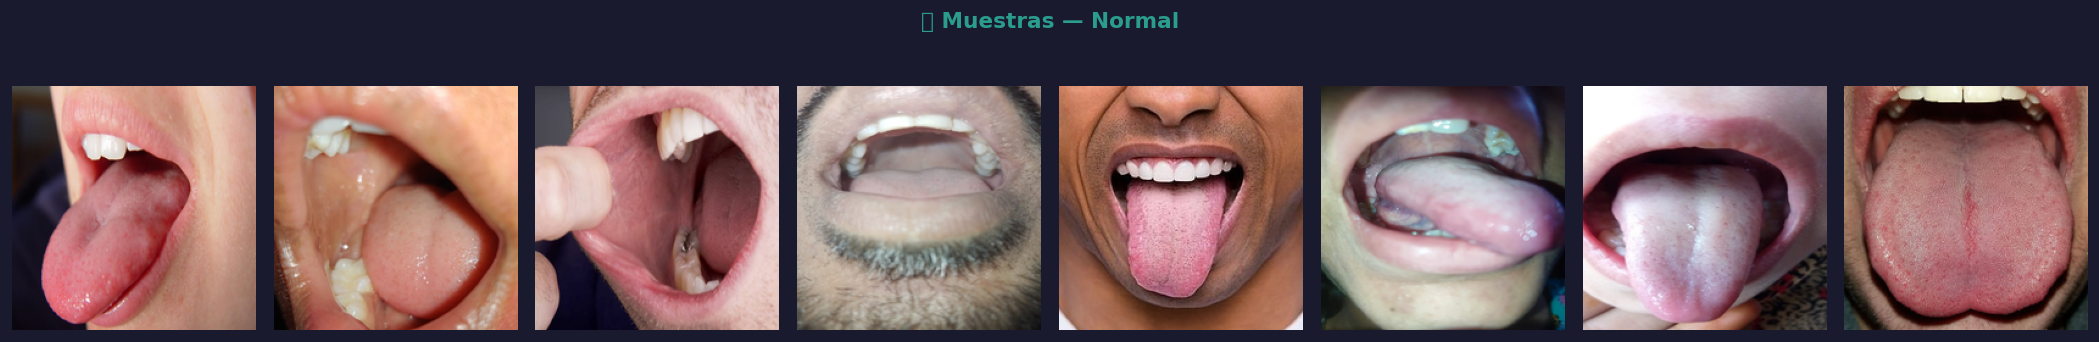

In [12]:
np.random.seed(42)

def show_sample_grid(df, class_name, color, n=8, label='Cancer', target_size=(200, 200)):
    """Muestra una cuadrícula de imágenes de muestra de una clase."""
    subset = df[df['class_name'] == class_name].dropna(subset=['width'])
    sample = subset.sample(min(n, len(subset)), random_state=42)['filepath'].tolist()

    cols = min(n, 8)
    fig, axes = plt.subplots(1, cols, figsize=(cols * 2.2, 2.8))
    fig.patch.set_facecolor('#1a1a2e')
    fig.suptitle(f'🔬 Muestras — {label}', fontsize=13, fontweight='bold',
                 color=color, y=1.03)

    for ax, fp in zip(axes, sample):
        try:
            img = Image.open(fp).convert('RGB').resize(target_size, Image.LANCZOS)
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center', color='red')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
            spine.set_visible(True)
    plt.tight_layout()
    plt.show()

show_sample_grid(df_valid, 'Oral Cancer photos', PALETTE['cancer'], n=8, label='Oral Cancer')
show_sample_grid(df_valid, 'normal', PALETTE['normal'], n=8, label='Normal')

---
## 12. Histograma de Píxeles Promedio (canal a canal)

⏳ Calculando histogramas promedio (muestra de 100 imágenes por clase)...
✅ Listo.


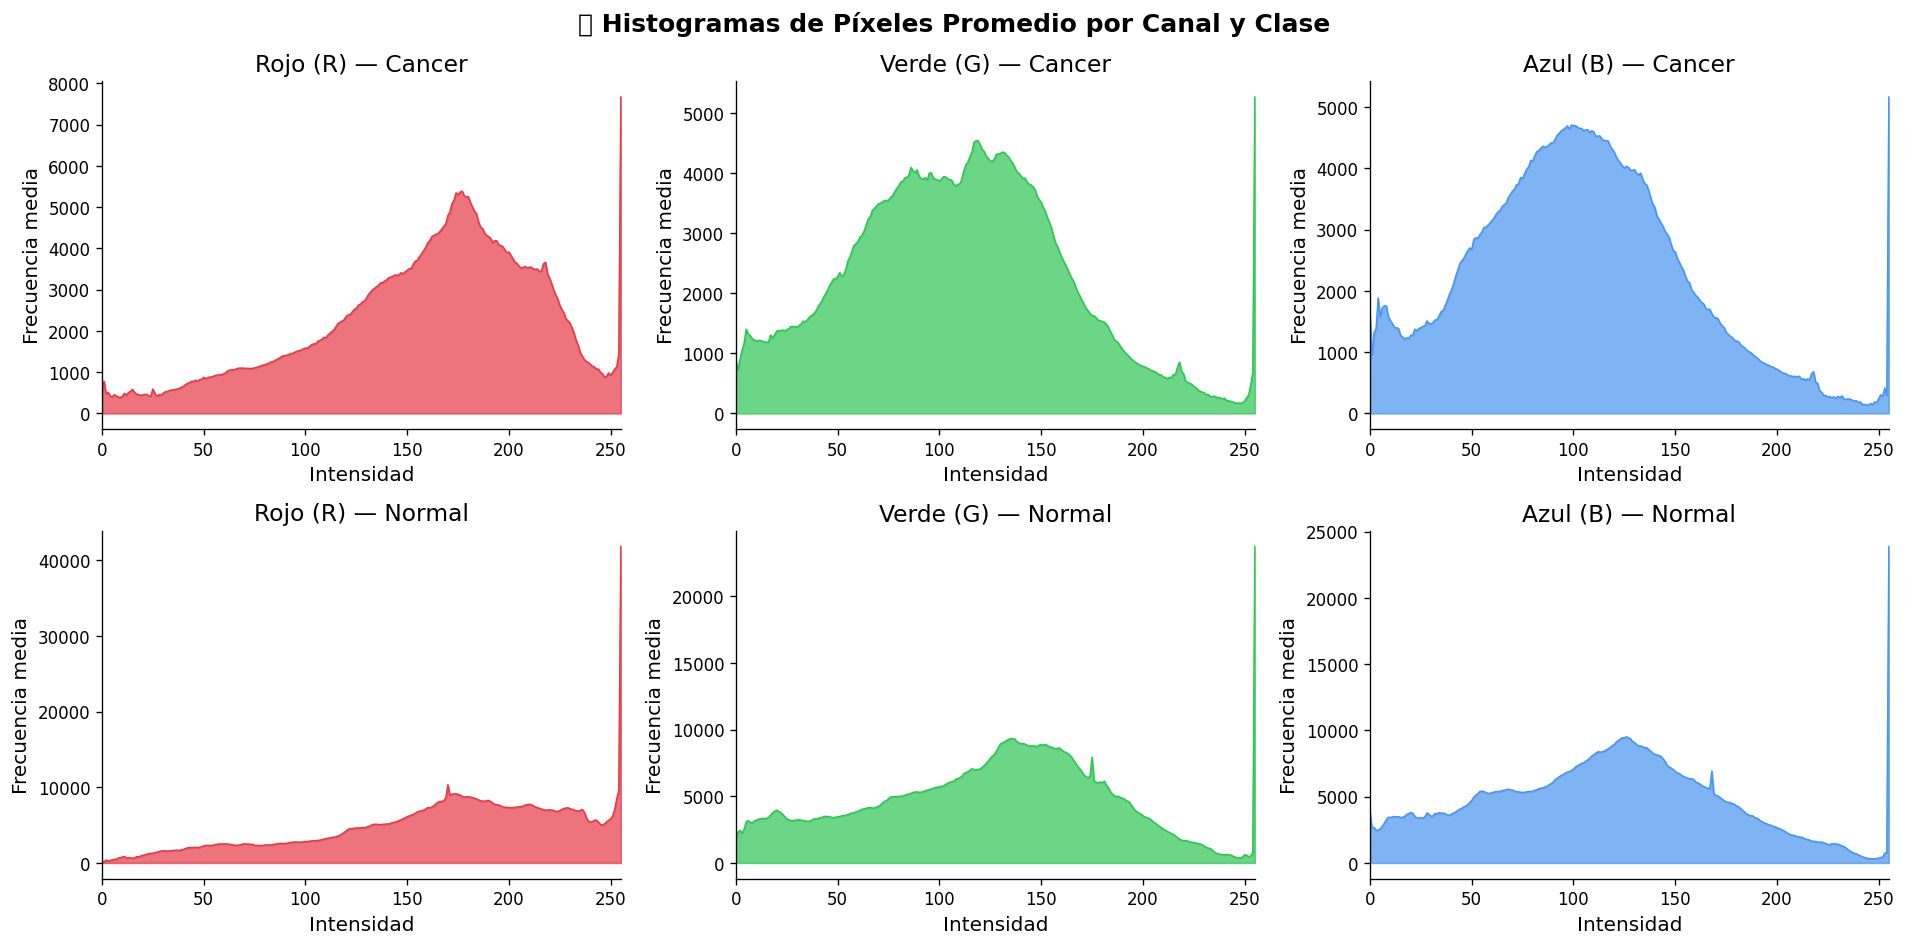

In [13]:
def compute_class_histogram(df, class_name, n_sample=100):
    """Computa el histograma promedio de los canales RGB de una muestra de imágenes."""
    subset = df[df['class_name'] == class_name].dropna(subset=['width'])
    sample = subset.sample(min(n_sample, len(subset)), random_state=42)['filepath'].tolist()

    hists = {0: np.zeros(256), 1: np.zeros(256), 2: np.zeros(256)}
    count = 0
    for fp in sample:
        try:
            img = np.array(Image.open(fp).convert('RGB'))
            for ch in range(3):
                h, _ = np.histogram(img[:, :, ch], bins=256, range=(0, 256))
                hists[ch] += h
            count += 1
        except Exception:
            pass
    if count:
        for ch in range(3):
            hists[ch] /= count
    return hists

print('⏳ Calculando histogramas promedio (muestra de 100 imágenes por clase)...')
hist_cancer = compute_class_histogram(df_valid, 'Oral Cancer photos', 100)
hist_normal = compute_class_histogram(df_valid, 'normal', 100)
print('✅ Listo.')

ch_names  = ['Rojo (R)', 'Verde (G)', 'Azul (B)']
ch_colors = ['#E63946', '#2DC653', '#4895EF']
bins      = np.arange(256)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('📈 Histogramas de Píxeles Promedio por Canal y Clase', fontsize=15, fontweight='bold')

for ch_idx, (ch_name, ch_color) in enumerate(zip(ch_names, ch_colors)):
    axes[0][ch_idx].fill_between(bins, hist_cancer[ch_idx], alpha=0.7, color=ch_color)
    axes[0][ch_idx].plot(bins, hist_cancer[ch_idx], color=ch_color, linewidth=0.8)
    axes[0][ch_idx].set_title(f'{ch_name} — Cancer')
    axes[0][ch_idx].set_xlabel('Intensidad')
    axes[0][ch_idx].set_ylabel('Frecuencia media')
    axes[0][ch_idx].set_xlim(0, 255)

    axes[1][ch_idx].fill_between(bins, hist_normal[ch_idx], alpha=0.7, color=ch_color)
    axes[1][ch_idx].plot(bins, hist_normal[ch_idx], color=ch_color, linewidth=0.8)
    axes[1][ch_idx].set_title(f'{ch_name} — Normal')
    axes[1][ch_idx].set_xlabel('Intensidad')
    axes[1][ch_idx].set_ylabel('Frecuencia media')
    axes[1][ch_idx].set_xlim(0, 255)

plt.tight_layout()
plt.show()

---
## 13. Detección de Imágenes Problemáticas

⚠️  Imágenes problemáticas por clase y criterio:
                    flag_tiny  flag_dark  flag_overexposed  flag_low_contrast  flag_tiny_file
class_name                                                                                   
Oral Cancer photos          0          0                 0                  0               5
normal                      0          0                 0                  0              13

🔢 Totales:
   flag_tiny             :    0 (0.0%)
   flag_dark             :    0 (0.0%)
   flag_overexposed      :    0 (0.0%)
   flag_low_contrast     :    0 (0.0%)
   flag_tiny_file        :   18 (1.5%)


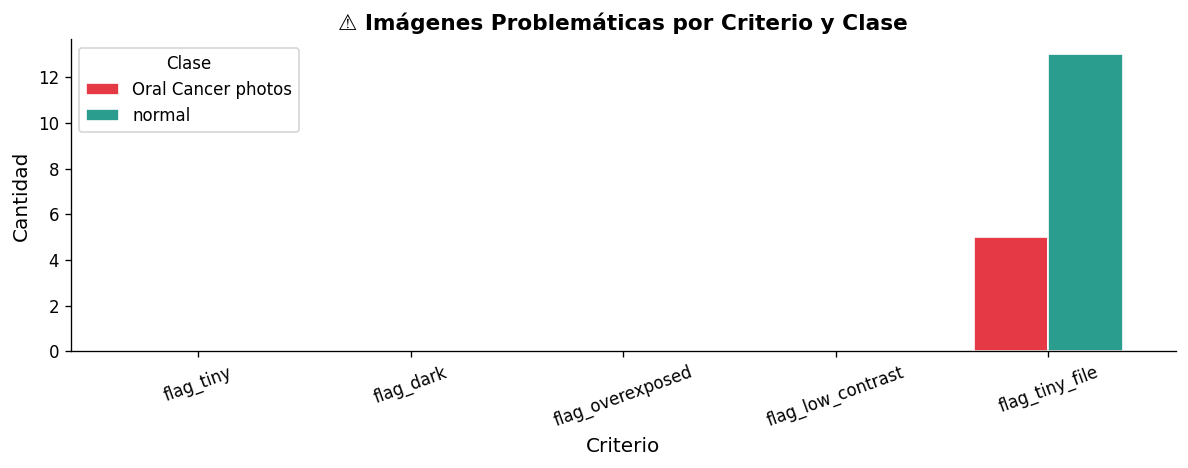

In [14]:
TINY_THRESHOLD     = 50
LOW_BRIGHT         = 20
HIGH_BRIGHT        = 235
LOW_CONTRAST       = 10
TINY_FILE_KB       = 5

df_valid['flag_tiny']         = (df_valid['width']  < TINY_THRESHOLD) | \
                                (df_valid['height'] < TINY_THRESHOLD)
df_valid['flag_dark']         = df_valid['brightness'] < LOW_BRIGHT
df_valid['flag_overexposed']  = df_valid['brightness'] > HIGH_BRIGHT
df_valid['flag_low_contrast'] = df_valid['contrast']   < LOW_CONTRAST
df_valid['flag_tiny_file']    = df_valid['file_size_kb'] < TINY_FILE_KB

flag_cols = ['flag_tiny','flag_dark','flag_overexposed','flag_low_contrast','flag_tiny_file']
flags_summary = df_valid[flag_cols + ['class_name']].groupby('class_name')[flag_cols].sum()

print("⚠️  Imágenes problemáticas por clase y criterio:")
print(flags_summary.to_string())

print("\n🔢 Totales:")
for col in flag_cols:
    count = df_valid[col].sum()
    pct   = count / len(df_valid) * 100
    print(f"   {col:<22}: {count:>4} ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
flags_summary.T.plot(kind='bar', ax=ax,
                     color=[PALETTE['cancer'], PALETTE['normal']],
                     edgecolor='white', width=0.7)
ax.set_title('⚠️ Imágenes Problemáticas por Criterio y Clase', fontsize=13, fontweight='bold')
ax.set_xlabel('Criterio')
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Clase')
plt.tight_layout()
plt.show()

---
## 14. Análisis Estadístico Inferencial — Test de Mann-Whitney


📊 Test de Mann-Whitney (α = 0.05)
───────────────────────────────────────────────────────────────────────────
     Feature  Cancer (media)  Normal (media)  U-statistic      p-value Significativo
aspect_ratio            1.25            1.03     260167.0 1.093896e-29             ✅
      height          516.86          887.94     132662.0 1.152577e-19             ✅
    contrast           45.83           50.53     138351.0 3.267177e-16             ✅
      mean_g          111.78          119.77     154719.0 2.926195e-08             ✅
      mean_b          107.08          114.74     158524.0 7.917975e-07             ✅
       width          623.07          815.54     158829.0 1.011762e-06             ✅
  brightness          126.25          132.65     163989.0 4.833666e-05             ✅
file_size_kb          146.76          193.61     170351.0 2.317178e-03             ✅
      mean_r          161.95          164.72     185362.0 5.182831e-01             ❌


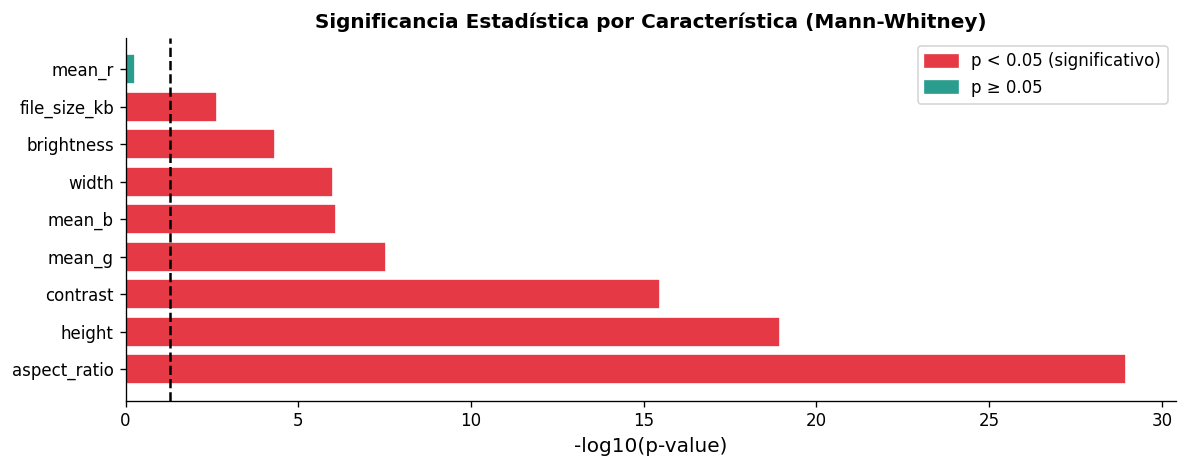

In [15]:
features_to_test = ['mean_r','mean_g','mean_b','brightness','contrast',
                    'file_size_kb','width','height','aspect_ratio']

cancer_df = df_valid[df_valid['label'] == 1]
normal_df = df_valid[df_valid['label'] == 0]

results = []
for feat in features_to_test:
    g1 = cancer_df[feat].dropna()
    g2 = normal_df[feat].dropna()
    stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    results.append({
        'Feature'        : feat,
        'Cancer (media)' : round(g1.mean(), 2),
        'Normal (media)' : round(g2.mean(), 2),
        'U-statistic'    : round(stat, 0),
        'p-value'        : p,
        'Significativo'  : '✅' if p < 0.05 else '❌'
    })

df_test = pd.DataFrame(results).sort_values('p-value')
print("\n📊 Test de Mann-Whitney (α = 0.05)")
print("─" * 75)
print(df_test.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = [PALETTE['cancer'] if p < 0.05 else PALETTE['normal'] for p in df_test['p-value']]
ax.barh(df_test['Feature'], -np.log10(df_test['p-value'].clip(lower=1e-300)),
        color=bar_colors, edgecolor='white')
ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1.5, label='α=0.05')
ax.set_xlabel('-log10(p-value)')
ax.set_title('Significancia Estadística por Característica (Mann-Whitney)', fontsize=12, fontweight='bold')
patch1 = mpatches.Patch(color=PALETTE['cancer'], label='p < 0.05 (significativo)')
patch2 = mpatches.Patch(color=PALETTE['normal'], label='p ≥ 0.05')
ax.legend(handles=[patch1, patch2])
plt.tight_layout()
plt.show()

---
## 15. Resumen Ejecutivo del EDA

In [16]:
total         = len(df)
n_cancer      = int((df['label']==1).sum())
n_normal      = int((df['label']==0).sum())
n_corrupt     = int(df['is_corrupt'].sum())
n_problematic = int(df_valid[flag_cols].any(axis=1).sum())
ext_top       = df['extension'].value_counts().idxmax()
ratio         = round(n_cancer / n_normal, 3)
avg_w_cancer  = round(cancer_df['width'].mean())
avg_h_cancer  = round(cancer_df['height'].mean())
avg_w_normal  = round(normal_df['width'].mean())
avg_h_normal  = round(normal_df['height'].mean())

sig_feats = df_test[df_test['p-value'] < 0.05]['Feature'].tolist()
label_corr = df_corr.corr()['label'].drop('label').sort_values(key=abs, ascending=False)
top_corr  = label_corr.head(3).index.tolist()

print("=" * 65)
print("          📋  RESUMEN EJECUTIVO — EDA")
print("=" * 65)
print(f"""
🔢 VOLUMEN
   Total imágenes          : {total:,}
   Oral Cancer             : {n_cancer:,} ({n_cancer/total*100:.1f}%)
   Normal                  : {n_normal:,} ({n_normal/total*100:.1f}%)
   Razón Cancer/Normal     : {ratio:.3f}x
   Imágenes corruptas      : {n_corrupt}
   Imágenes problemáticas  : {n_problematic} ({n_problematic/len(df_valid)*100:.1f}%)

📁 FORMATOS
   Extensión predominante  : {ext_top}
   Extensiones presentes   : {', '.join(df['extension'].unique())}

📐 DIMENSIONES (media)
   Cancer  : {avg_w_cancer} × {avg_h_cancer} px
   Normal  : {avg_w_normal} × {avg_h_normal} px
   → Alta variabilidad de resolución; se requiere redimensionado uniforme.

🎨 COLOR
   Características significativas (Mann-Whitney α=0.05):
   → {', '.join(sig_feats) if sig_feats else 'Ninguna'}

   Top correlación con etiqueta  : {', '.join(top_corr)}

⚠️  HALLAZGOS CRÍTICOS
   1. Dataset medianamente desbalanceado (ratio {ratio:.2f}x).
      → Estrategia recomendada: class_weight='balanced' o oversampling.
   2. Alta variabilidad en resoluciones; tamaño de entrada deberá
      estandarizarse (ej. 224×224 ó 299×299 px).
   3. Imágenes de muy bajo tamaño de archivo pueden ser miniaturas
      o imágenes degradadas; considerar filtrado.
   4. Diversidad de formatos (.jpeg, .jpg, .png, .jfif, .webp);
      unificar a RGB en preprocesamiento.
   5. Las características de color muestran diferencias estadísticamente
      significativas entre clases → útiles como señal discriminante.

✅ PRÓXIMOS PASOS
   1. Preprocesamiento: resize, normalización [0,1], conversión RGB.
   2. Data augmentation: flip, rotate, zoom, color jitter.
   3. Split train/val/test (70/15/15) con estratificación.
   4. Baseline CNN → Transfer Learning (ResNet50 / EfficientNetB0).
""")
print("=" * 65)

          📋  RESUMEN EJECUTIVO — EDA

🔢 VOLUMEN
   Total imágenes          : 1,238
   Oral Cancer             : 685 (55.3%)
   Normal                  : 553 (44.7%)
   Razón Cancer/Normal     : 1.239x
   Imágenes corruptas      : 0
   Imágenes problemáticas  : 18 (1.5%)

📁 FORMATOS
   Extensión predominante  : .jpeg
   Extensiones presentes   : .jpeg, .jpg, .png, .webp, .jfif

📐 DIMENSIONES (media)
   Cancer  : 623 × 517 px
   Normal  : 816 × 888 px
   → Alta variabilidad de resolución; se requiere redimensionado uniforme.

🎨 COLOR
   Características significativas (Mann-Whitney α=0.05):
   → aspect_ratio, height, contrast, mean_g, mean_b, width, brightness, file_size_kb

   Top correlación con etiqueta  : aspect_ratio, height, contrast

⚠️  HALLAZGOS CRÍTICOS
   1. Dataset medianamente desbalanceado (ratio 1.24x).
      → Estrategia recomendada: class_weight='balanced' o oversampling.
   2. Alta variabilidad en resoluciones; tamaño de entrada deberá
      estandarizarse (ej. 224×224 ó